#  Tutorial 2: Visium Fluorescence Data
**10x Genomics Spatial Methods Assignment**

In this notebook we analyze 10x Visium data paired with a **fluorescence microscopy image** (instead of H&E). We use `squidpy` which adds spatial statistics on top of scanpy.

## Step 1 — Install Libraries

In [1]:
!pip install scanpy squidpy leidenalg -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 961.1 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.3/192.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5

## Step 2 — Import Libraries

In [2]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import numpy as np

sc.set_figure_params(facecolor="white", figsize=(8, 8))
print("Libraries loaded ✅")

Libraries loaded ✅


## Step 3 — Load the Fluorescence Visium Dataset
Squidpy has built-in datasets. This downloads automatically.

In [3]:
adata = sq.datasets.visium_fluo_adata()
print(adata)
print("\nImage keys:", list(adata.uns["spatial"].keys()))

INFO     Downloading visium_fluo_adata.h5ad from                                                                   
         https://exampledata.scverse.org/squidpy/figshare/visium_fluo_adata.h5ad                                   


  0%|                                               | 0.00/254M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2800 × 16562
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'MT', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

Image keys: ['V1_Adult_Mouse_Brain_Coronal_Section_2']


## Step 4 — Explore the Tissue Image
The fluorescence image shows different channels (e.g. DAPI, different protein markers).

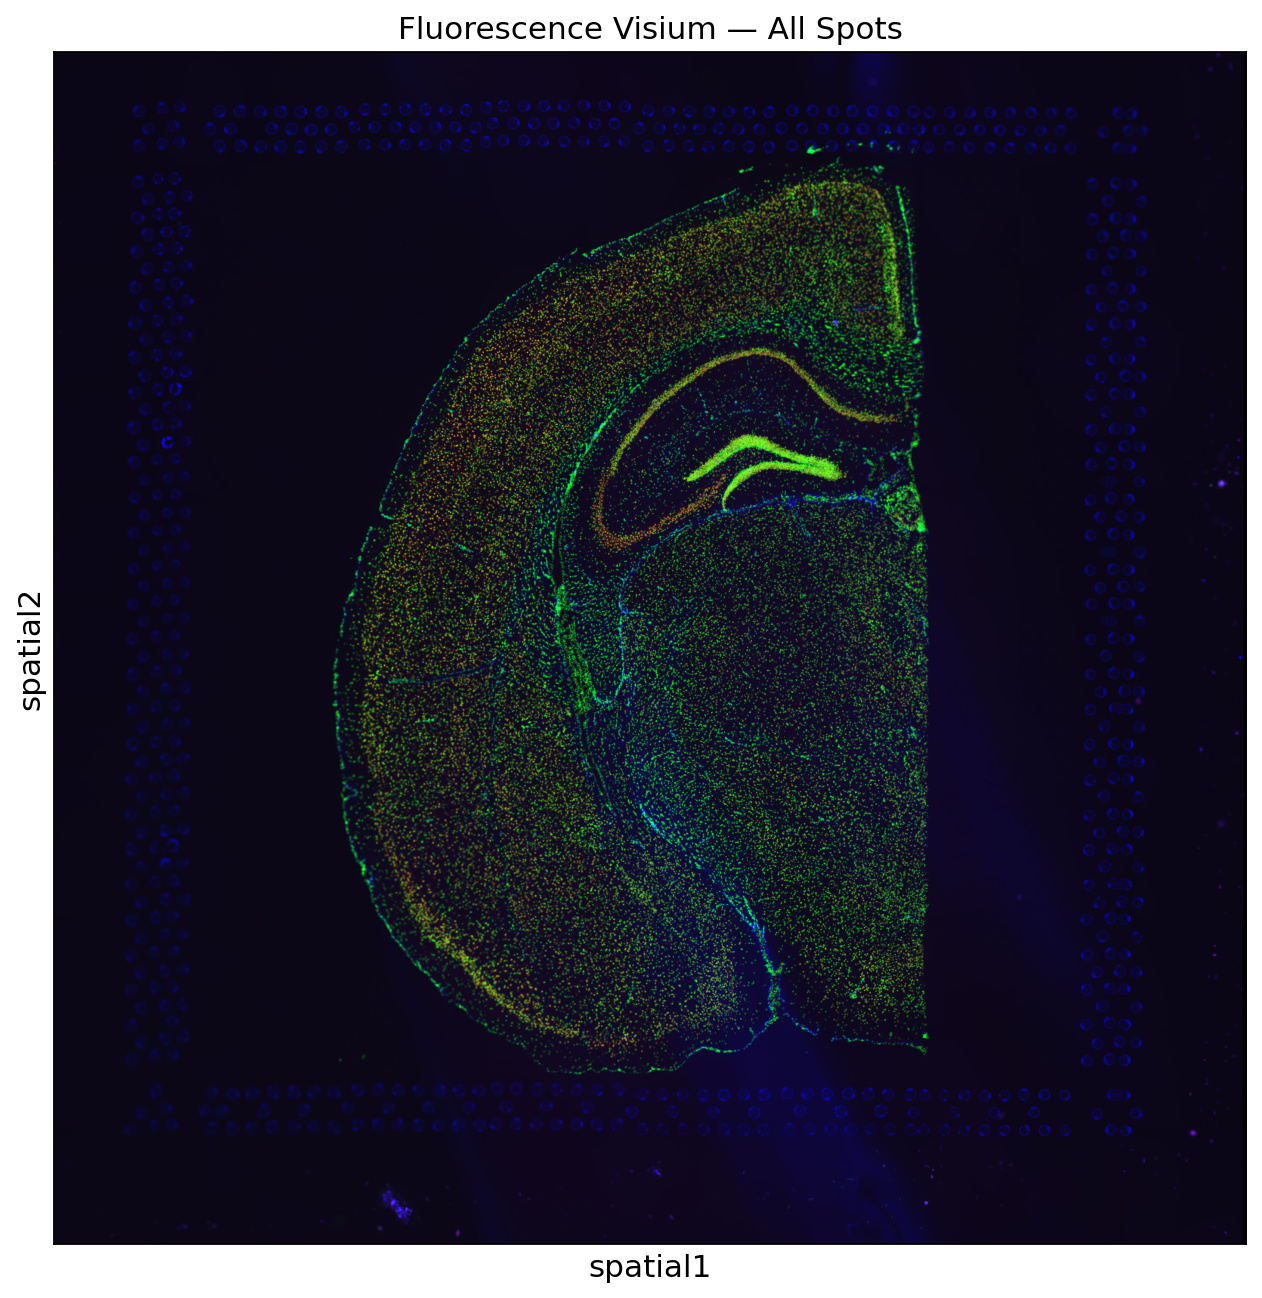

In [4]:
sq.pl.spatial_scatter(
    adata,
    shape="circle",
    size=0.5,
    title="Fluorescence Visium — All Spots"
)

## Step 5 — QC, Normalize, Cluster

In [5]:
# QC
sc.pp.calculate_qc_metrics(adata, inplace=True)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.filter_cells(adata, min_genes=200)

# Normalize
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000)

# Dimensionality reduction + clustering
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, key_added="clusters")
print("Clustering done ✅")

/tmp/ipykernel_15936/2635672413.py:15: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added="clusters")


Clustering done ✅


## Step 6 — Spatial Scatter Plot of Clusters

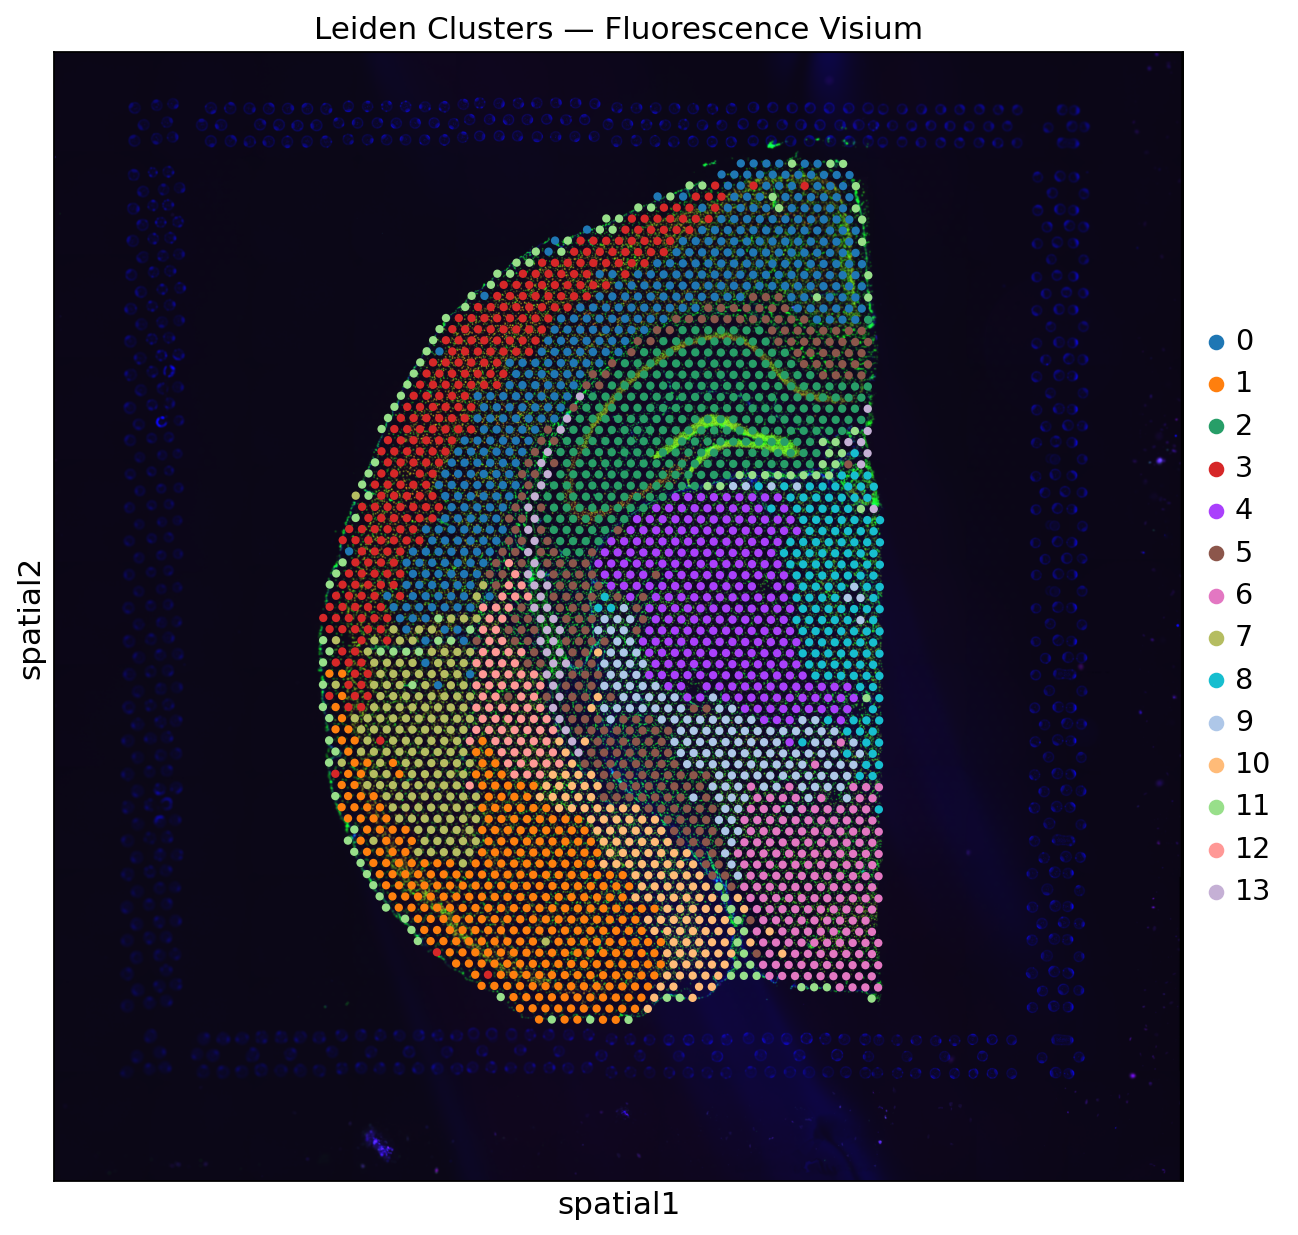

In [6]:
sq.pl.spatial_scatter(adata, color="clusters", title="Leiden Clusters — Fluorescence Visium")

## Step 7 — Extract Image Features
Squidpy can extract texture and summary statistics from the fluorescence image for each spot.

In [7]:
sq.im.calculate_image_features(
    adata,
    sq.im.ImageContainer.from_adata(adata),
    features="summary",
    key_added="img_features"
)
print("Image features extracted ✅")
print(adata.obsm["img_features"].head())

  0%|          | 0/2800 [00:00<?, ?/s]

Image features extracted ✅
                    summary_ch-0_quantile-0.9  summary_ch-0_quantile-0.5  \
AAACAAGTATCTCCCA-1                   0.147451                   0.070588   
AAACAGAGCGACTCCT-1                   0.058824                   0.054902   
AAACAGTGTTCCTGGG-1                   0.070588                   0.070588   
AAACATTTCCCGGATT-1                   0.145098                   0.070588   
AAACCGGGTAGGTACC-1                   0.235294                   0.105882   

                    summary_ch-0_quantile-0.1  summary_ch-0_mean  \
AAACAAGTATCTCCCA-1                   0.066667           0.089307   
AAACAGAGCGACTCCT-1                   0.054902           0.057133   
AAACAGTGTTCCTGGG-1                   0.066667           0.071163   
AAACATTTCCCGGATT-1                   0.066667           0.094745   
AAACCGGGTAGGTACC-1                   0.078431           0.134449   

                    summary_ch-0_std  summary_ch-1_quantile-0.9  \
AAACAAGTATCTCCCA-1          0.046468    

## Step 8 — Build Spatial Neighborhood Graph
Connect spots that are physically adjacent to each other.

In [8]:
sq.gr.spatial_neighbors(adata)
print("Spatial neighbors graph built ✅")

INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
Spatial neighbors graph built ✅


## Step 9 — Ripley's Statistics (Spatial Distribution)
Tests whether clusters of spots are more spatially concentrated than expected by chance.

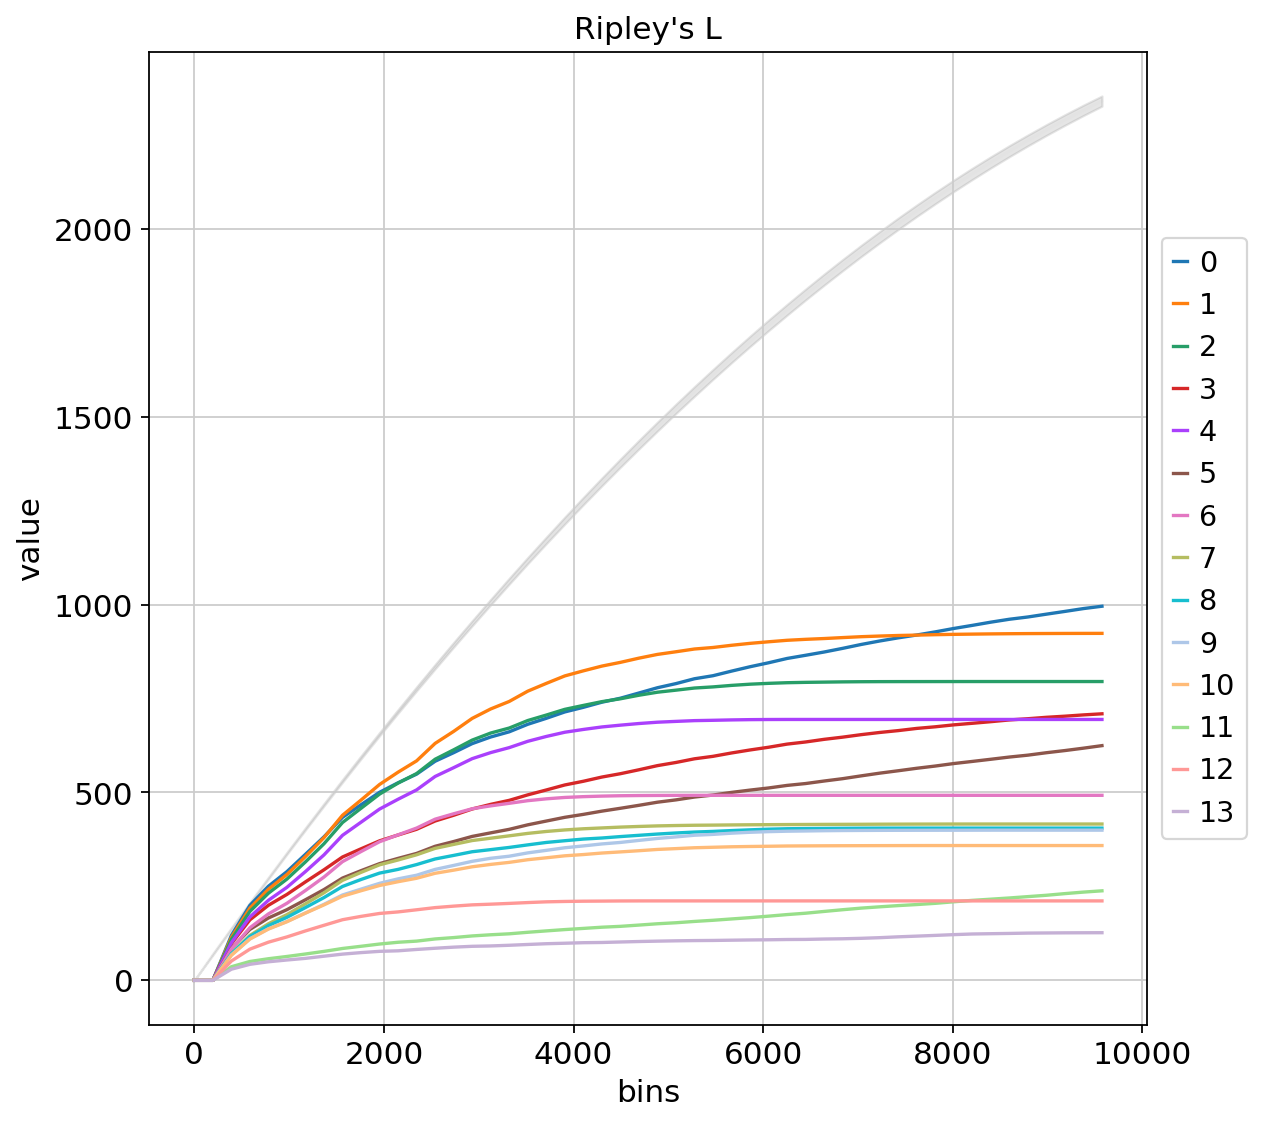

In [9]:
sq.gr.ripley(adata, cluster_key="clusters", mode="L")
sq.pl.ripley(adata, cluster_key="clusters", mode="L")

##  Tutorial 2 Complete!
We have:
- Loaded fluorescence Visium data
- Clustered and visualized spatially
- Extracted image features from the fluorescence image
- Built a spatial neighbors graph
- Run Ripley's L statistic for spatial distribution analysis